# Student Final Grade (G3) Prediction

**AI & Data Science Diploma Project**
Predicting a secondary school student's final grade (G3) from demographic, social, and academic features.

## 1. Introduction

### 1.1 Project Overview

Student performance is influenced by many factors beyond raw ability: family background, study habits, social life, and school support all leave a mark on final grades. In this project we work with real survey data collected from students of a Mathematics course in two Portuguese secondary schools, and we build a regression model that predicts a student's **final grade (G3)**, on a 0-20 scale, from the rest of their profile.

The end-to-end workflow followed here is: understand the data, clean it, explore it visually, engineer a handful of new features, encode and scale everything inside a single leak-free `Pipeline`, train and tune several regression algorithms, compare them fairly, and finally package the best one for deployment through a Streamlit app.

### 1.2 Data Description

This dataset is a renamed version of the well-known **UCI "Student Alcohol Consumption" / Student Performance (Math)** dataset originally published on Kaggle (`uciml/student-alcohol-consumption`, source study: Cortez & Silva, 2008). It contains **395 students** described by **33 attributes**: demographics (school, sex, age, address type), family background (family size, parents' status, parents' education and jobs), school-related attributes (study time, travel time, past class failures, extra support), social/lifestyle attributes (going out, alcohol consumption, free time, romantic relationships, health), and three grades: `G1` (1st period), `G2` (2nd period) and `G3` (final grade, our target).

The columns in this copy of the dataset have been renamed to more descriptive English names (e.g. `Medu` -> `Mother_edu`, `Fedu` -> `Father_edu`, `Mjob`/`Fjob` -> `Mother_job`/`Father_job`, `Pstatus` -> `Parrent_status`, `schoolsup`/`famsup` -> `extra_edu_supp`/`family_edu_supp`, `paid` -> `extra_paid_class`, `activities` -> `extra_curr_activities`, `higher` -> `Interested_in_higher_edu`, `internet` -> `internet_access`, `romantic` -> `romantic_relationship`, `famrel` -> `Family_quality_reln`, `freetime` -> `freetime_after_school`, `goout` -> `goout_with_friends`, `Dalc`/`Walc` -> `workday_alcohol_consum`/`weekend_alcohol_consum`, `health` -> `health_status`), but the underlying values and meaning are unchanged from the original Kaggle source.

**Important note from the original dataset description:** `G3` has a strong relationship with `G1` and `G2`. This is expected and *not* data leakage — `G1` and `G2` are grades issued in earlier periods of the same school year, so they are legitimately known before the final grade `G3` is decided.

### 1.3 Project Objectives

- Load and understand the dataset, grounding every feature in the original Kaggle description.
- Perform Exploratory Data Analysis (EDA) and visualize the key relationships with the target.
- Clean the data (missing values, duplicates) and engineer a few informative new features.
- Build a single leak-free preprocessing + modelling `Pipeline` (imputation, encoding, scaling).
- Train and tune multiple regression models with `GridSearchCV`.
- Compare all models on held-out test data using R², MAE, MSE and RMSE.
- Select, explain and save the best model as one deployable pipeline.
- Ship a Streamlit app that loads the saved pipeline and predicts G3 from user input.

### 1.4 Why compare several regression models?

No single algorithm is best for every dataset. Linear models (`LinearRegression`, `Ridge`, `Lasso`) are simple, interpretable baselines that work well when relationships are roughly linear. Tree-based ensembles (`RandomForest`, `GradientBoosting`, `XGBoost`, `ExtraTrees`) can capture non-linear interactions between features (e.g. between failures, study time and alcohol consumption) without much manual feature engineering. Instance-based / kernel methods (`KNN`, `SVR`) offer yet another modelling perspective. Training all of them side by side, with hyperparameters tuned fairly through cross-validation, lets us pick the genuinely best model instead of assuming one family is superior in advance.

### 1.5 Why Pipeline + GridSearchCV?

A **Pipeline** chains every preprocessing step (imputation, encoding, scaling) together with the final estimator into a single object. This guarantees that preprocessing statistics (like the scaler's mean/std, or which categories were seen) are learned **only on the training fold**, then applied unchanged to validation/test data — avoiding data leakage. `GridSearchCV` wraps a pipeline in an exhaustive search over a hyperparameter grid, using cross-validation to pick the combination that generalizes best, rather than the one that simply looks best on a single split.

## 2. Importing Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


We import only the libraries we need. `pandas`/`numpy` handle data manipulation, `matplotlib`/`seaborn` handle visualization, `scikit-learn` provides preprocessing tools, the pipeline machinery, the regression models and evaluation metrics, `xgboost` adds the gradient-boosted `XGBRegressor`, and `joblib` will be used to persist the final pipeline.

## 3. Loading the Dataset

In [2]:
data = pd.read_csv("student-mat.csv")
df = data.copy()
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,school,sex,age,address,famsize,Parrent_status,Mother_edu,Father_edu,Mother_job,Father_job,...,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


We load the CSV with `pandas.read_csv()` and immediately work on a `.copy()` (`df`) so the original `data` stays untouched as a reference. The first five rows already show a mix of categorical (`school`, `sex`, `Mother_job`...) and numeric/ordinal (`age`, `traveltime`, `G1`, `G2`, `G3`...) columns.

## 4. Dataset Overview

In [3]:
print("Dataset Shape:", df.shape)
print()
print("Column Names and Data Types:")
print(df.dtypes)

Dataset Shape: (395, 33)

Column Names and Data Types:
school                        str
sex                           str
age                         int64
address                       str
famsize                       str
Parrent_status                str
Mother_edu                  int64
Father_edu                  int64
Mother_job                    str
Father_job                    str
reason_to_chose_school        str
guardian                      str
traveltime                  int64
weekly_studytime            int64
failures                    int64
extra_edu_supp                str
family_edu_supp               str
extra_paid_class              str
extra_curr_activities         str
nursery                       str
Interested_in_higher_edu      str
internet_access               str
romantic_relationship         str
Family_quality_reln         int64
freetime_after_school       int64
goout_with_friends          int64
workday_alcohol_consum      int64
weekend_alcohol_consum     

**Observations:**
- The dataset has **395 rows** and **33 columns** (32 features + target `G3`).
- Most columns are either integers (grades, scales like `Family_quality_reln` 1-5, counts like `absences`) or text/categorical (`school`, `sex`, job columns, yes/no flags).

In [4]:
df.describe()

,age,Mother_edu,Father_edu,traveltime,weekly_studytime,failures,Family_quality_reln,freetime_after_school,goout_with_friends,workday_alcohol_consum,weekend_alcohol_consum,health_status,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


The statistical summary confirms several columns are on small fixed integer scales (e.g. `Mother_edu`/`Father_edu` 0-4, `Family_quality_reln`/`freetime_after_school`/`goout_with_friends`/`health_status` 1-5, `workday_alcohol_consum`/`weekend_alcohol_consum` 1-5), while `age`, `absences`, `G1`, `G2`, `G3` behave more like continuous numeric variables. `G1`, `G2` and `G3` all range 0-20 as expected for grades.

In [5]:
df.describe(include="object")

,school,sex,address,famsize,Parrent_status,Mother_job,Father_job,reason_to_chose_school,guardian,extra_edu_supp,family_edu_supp,extra_paid_class,extra_curr_activities,nursery,Interested_in_higher_edu,internet_access,romantic_relationship
count,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395,395
unique,2,2,2,2,2,5,5,4,3,2,2,2,2,2,2,2,2
top,GP,F,U,GT3,T,other,other,course,mother,no,yes,no,yes,yes,yes,yes,no
freq,349,208,307,281,354,141,217,145,273,344,242,214,201,314,375,329,263


All the categorical columns (`school`, `sex`, `address`, `famsize`, `Parrent_status`, job columns, `reason_to_chose_school`, `guardian`, and the yes/no support/lifestyle flags) have a small number of clean, consistent categories with no obvious typos.

## 5. Kaggle Dataset Description Summary

This is a renamed copy of the UCI **"Student Alcohol Consumption" (Math course)** dataset from Kaggle. Reading the original dataset description on Kaggle clarifies what every column means:

| Column in this file | Original name | Meaning |
|---|---|---|
| `school` | school | Student's school (`GP`=Gabriel Pereira, `MS`=Mousinho da Silveira) |
| `sex` | sex | Student's sex (`F`/`M`) |
| `age` | age | Student's age (15-22) |
| `address` | address | Home address type (`U`=urban, `R`=rural) |
| `famsize` | famsize | Family size (`LE3`=<=3, `GT3`=>3) |
| `Parrent_status` | Pstatus | Parents' cohabitation status (`T`=living together, `A`=apart) |
| `Mother_edu` / `Father_edu` | Medu/Fedu | Mother's/Father's education, 0 (none) to 4 (higher education) |
| `Mother_job` / `Father_job` | Mjob/Fjob | Mother's/Father's job category |
| `reason_to_chose_school` | reason | Reason to choose this school (course preference, home proximity, reputation, other) |
| `guardian` | guardian | Student's guardian (mother, father, other) |
| `traveltime` | traveltime | Home-to-school travel time, 1 (<15 min) to 4 (>1 hour) |
| `weekly_studytime` | studytime | Weekly study time, 1 (<2h) to 4 (>10h) |
| `failures` | failures | Number of past class failures (0 to 3+) |
| `extra_edu_supp` | schoolsup | Extra educational support from the school (yes/no) |
| `family_edu_supp` | famsup | Family educational support (yes/no) |
| `extra_paid_class` | paid | Extra paid classes within the course subject (yes/no) |
| `extra_curr_activities` | activities | Extra-curricular activities (yes/no) |
| `nursery` | nursery | Attended nursery school (yes/no) |
| `Interested_in_higher_edu` | higher | Wants to pursue higher education (yes/no) |
| `internet_access` | internet | Internet access at home (yes/no) |
| `romantic_relationship` | romantic | In a romantic relationship (yes/no) |
| `Family_quality_reln` | famrel | Quality of family relationships, 1 (very bad) to 5 (excellent) |
| `freetime_after_school` | freetime | Free time after school, 1 (very low) to 5 (very high) |
| `goout_with_friends` | goout | Going out with friends, 1 (very low) to 5 (very high) |
| `workday_alcohol_consum` | Dalc | Workday alcohol consumption, 1 (very low) to 5 (very high) |
| `weekend_alcohol_consum` | Walc | Weekend alcohol consumption, 1 (very low) to 5 (very high) |
| `health_status` | health | Current health status, 1 (very bad) to 5 (very good) |
| `absences` | absences | Number of school absences (0 to 93) |
| `G1` | G1 | First period grade, 0-20 |
| `G2` | G2 | Second period grade, 0-20 |
| `G3` | G3 | **Final grade, 0-20 (target variable)** |

Grasping these meanings up front is what allows the EDA and feature engineering below to make sense — e.g. we know `Mother_edu`/`Father_edu`, the alcohol columns and the 1-5 "quality" columns are ordinal scales rather than free numeric measurements.

## 6. Exploratory Data Analysis (EDA)

### 6.1 Target Variable Distribution (G3)

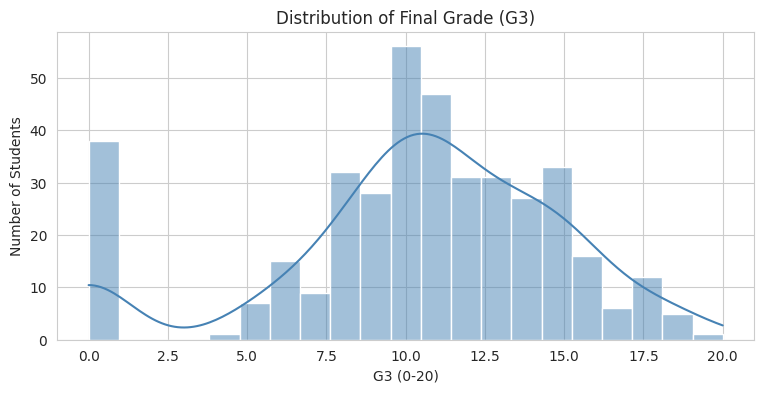

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Students with G3 == 0: 38


In [6]:
plt.figure(figsize=(9, 4))
sns.histplot(df["G3"], bins=21, kde=True, color="steelblue")
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3 (0-20)")
plt.ylabel("Number of Students")
plt.show()

print(df["G3"].describe())
print("\nStudents with G3 == 0:", (df["G3"] == 0).sum())

**Finding:** `G3` is roughly bell-shaped and centered around 10-12, but there is a small spike of students with `G3 = 0`. These are almost certainly students who dropped/failed the course outright rather than genuinely scoring zero knowledge, which is a known quirk of this dataset — we keep them since they are valid final outcomes, not data errors.

### 6.2 Relationship Between G1, G2 and G3

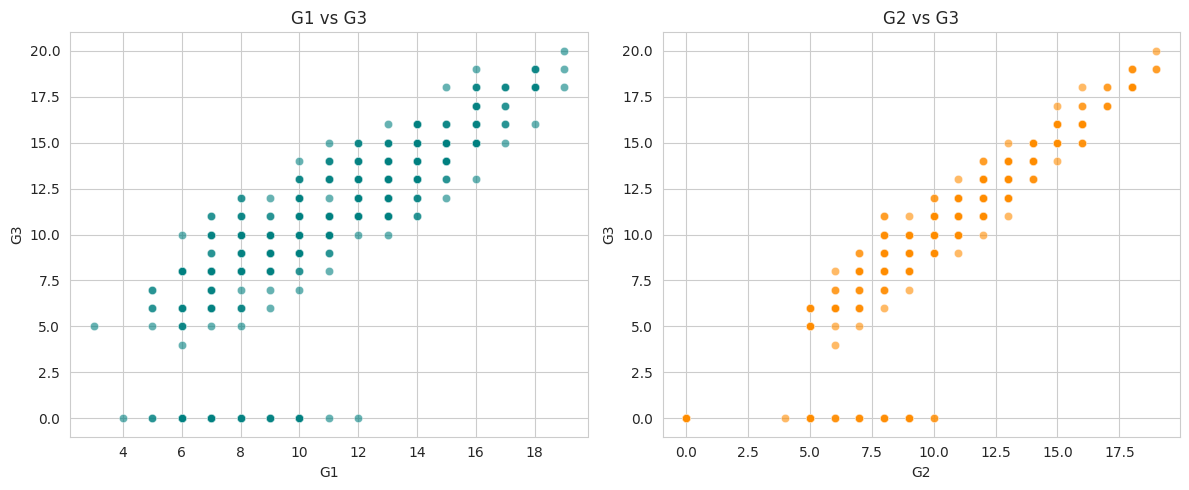

Correlation G1-G3: 0.801
Correlation G2-G3: 0.905


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="G1", y="G3", ax=axes[0], color="teal", alpha=0.6)
axes[0].set_title("G1 vs G3")
sns.scatterplot(data=df, x="G2", y="G3", ax=axes[1], color="darkorange", alpha=0.6)
axes[1].set_title("G2 vs G3")
plt.tight_layout()
plt.show()

print("Correlation G1-G3:", df["G1"].corr(df["G3"]).round(3))
print("Correlation G2-G3:", df["G2"].corr(df["G3"]).round(3))

**Finding:** Both `G1` and `G2` are very strongly correlated with `G3` (as documented in the original dataset description), with `G2` being the stronger predictor since it's temporally closer to the final grade. We keep both features — this is legitimate predictive signal from earlier grading periods, not leakage from the future.

### 6.3 Numerical Feature Distributions

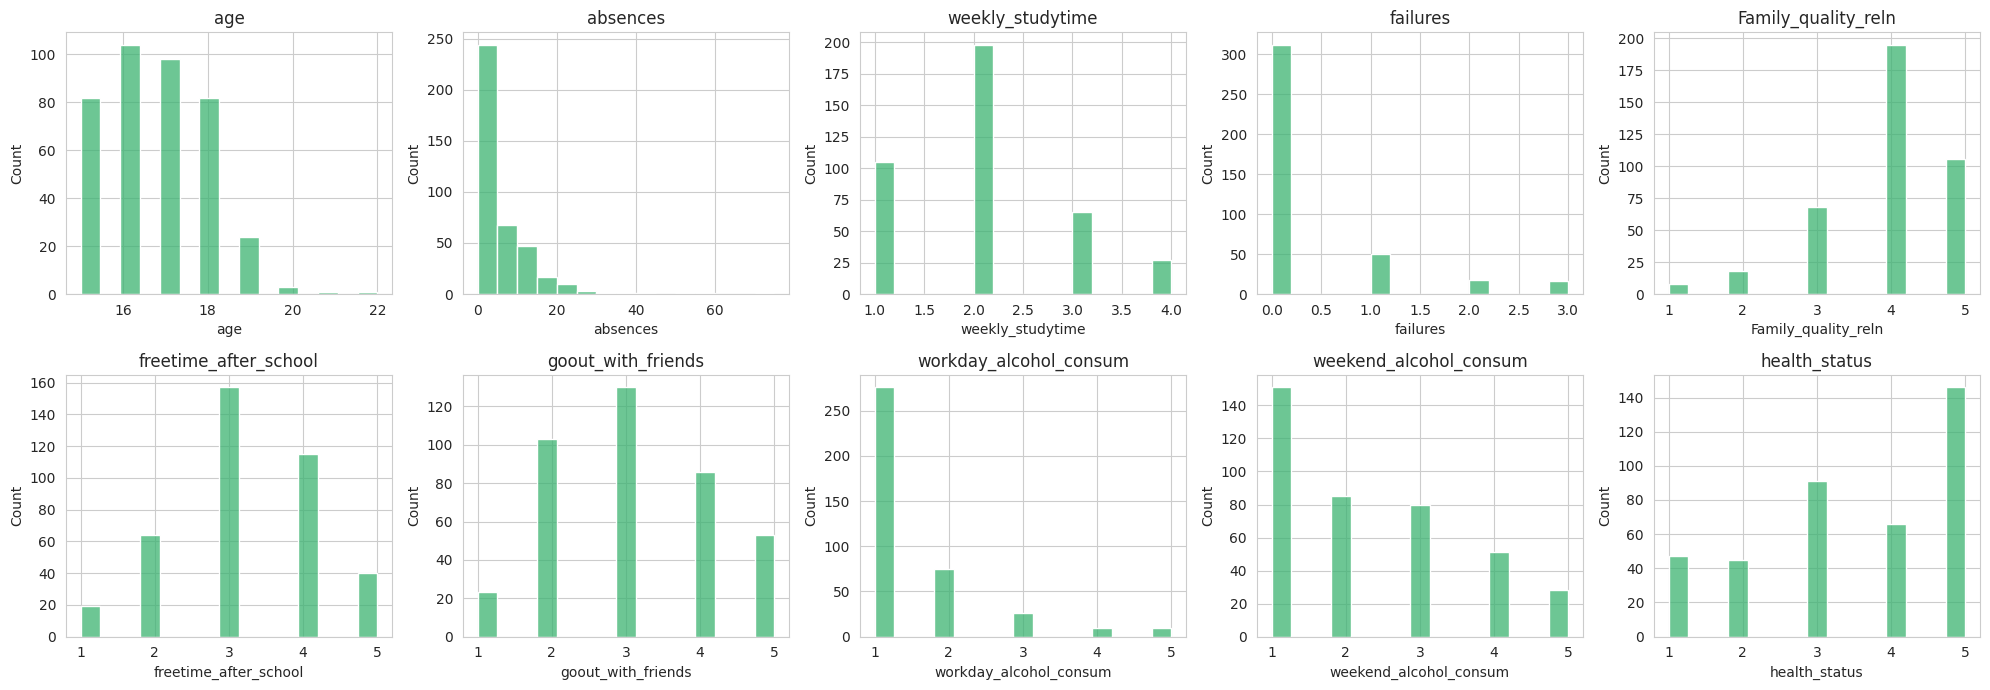

In [8]:
num_cols_raw = ["age", "absences", "weekly_studytime", "failures",
                "Family_quality_reln", "freetime_after_school", "goout_with_friends",
                "workday_alcohol_consum", "weekend_alcohol_consum", "health_status"]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), num_cols_raw):
    sns.histplot(df[col], bins=15, ax=ax, color="mediumseagreen")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Finding:** `absences` is heavily right-skewed with a long tail (a few students miss many more classes than the rest). `failures` is dominated by zero. The 1-5 lifestyle scales (`Family_quality_reln`, `freetime_after_school`, `goout_with_friends`, alcohol consumption, `health_status`) each cluster around a few common values, consistent with survey-style ordinal data.

### 6.4 Categorical Features vs Final Grade

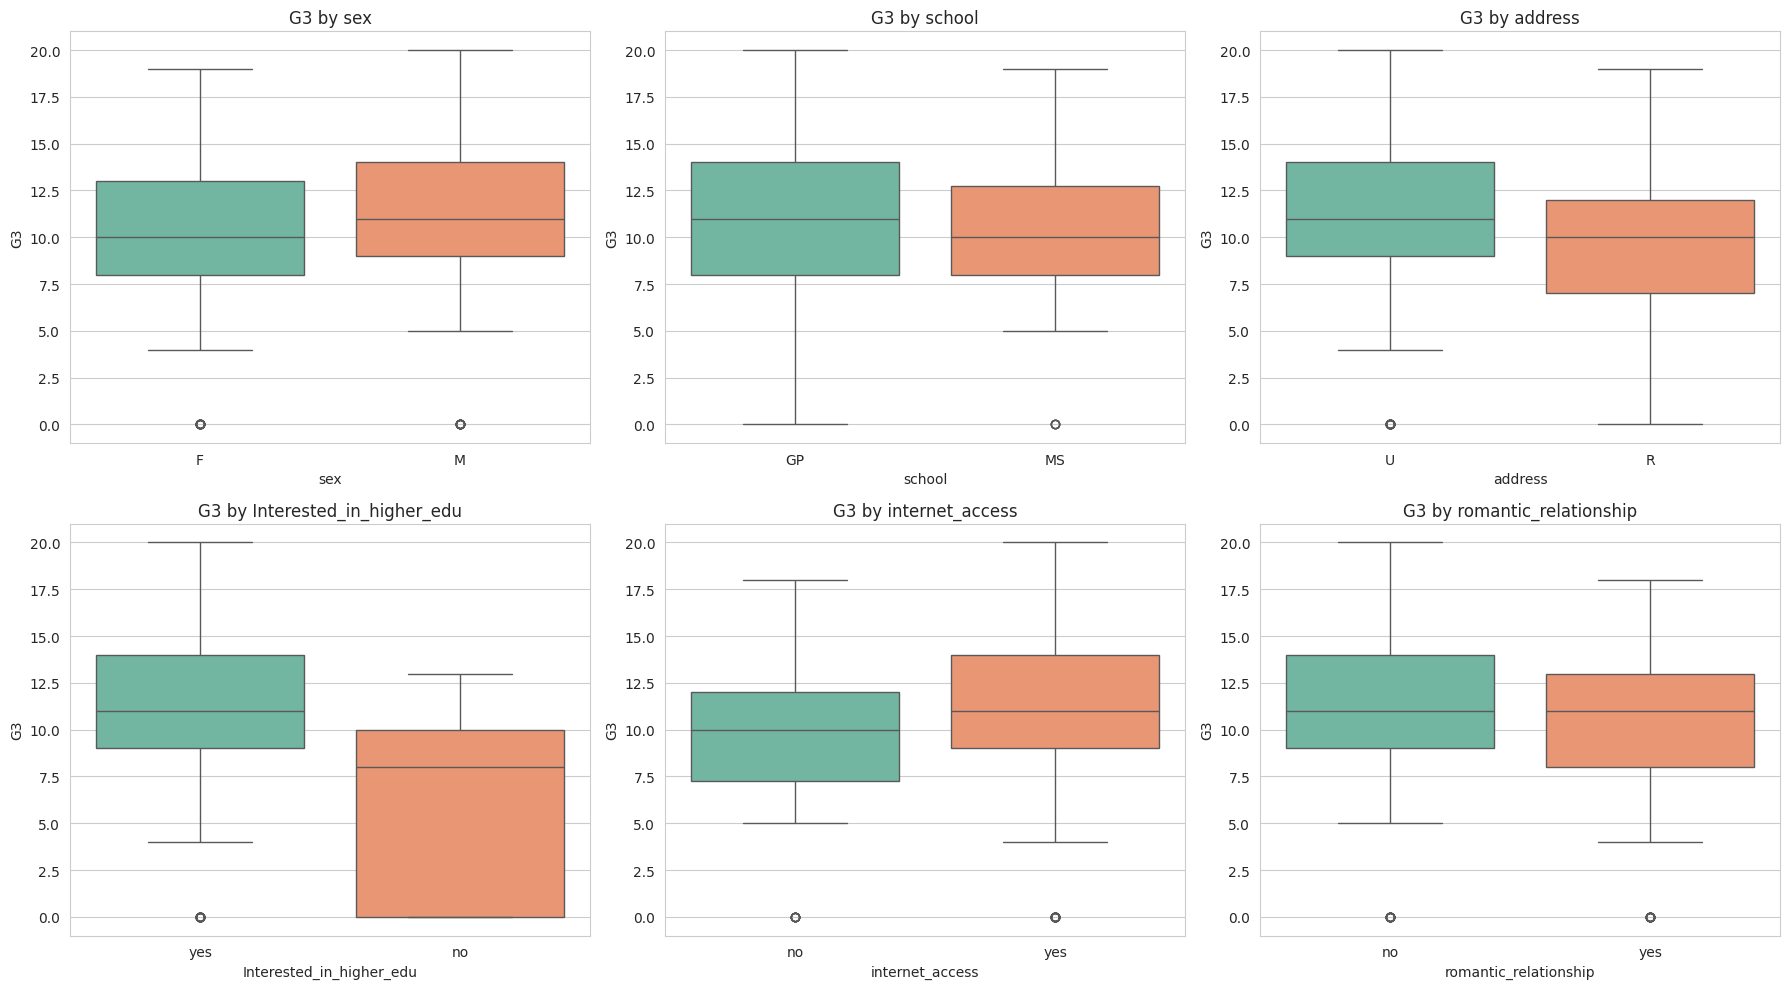

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_to_plot = ["sex", "school", "address", "Interested_in_higher_edu",
               "internet_access", "romantic_relationship"]
for ax, col in zip(axes.flatten(), cat_to_plot):
    sns.boxplot(data=df, x=col, y="G3", ax=ax, palette="Set2")
    ax.set_title(f"G3 by {col}")
plt.tight_layout()
plt.show()

**Finding:** Students who want to pursue higher education (`Interested_in_higher_edu = yes`) score noticeably higher on average — one of the clearest categorical splits in the data. Urban students (`address = U`) show a slightly higher median grade than rural students, plausibly linked to access/travel time. Sex, school, internet access and romantic relationship show smaller differences.

### 6.5 Study Time, Failures and Alcohol vs Final Grade

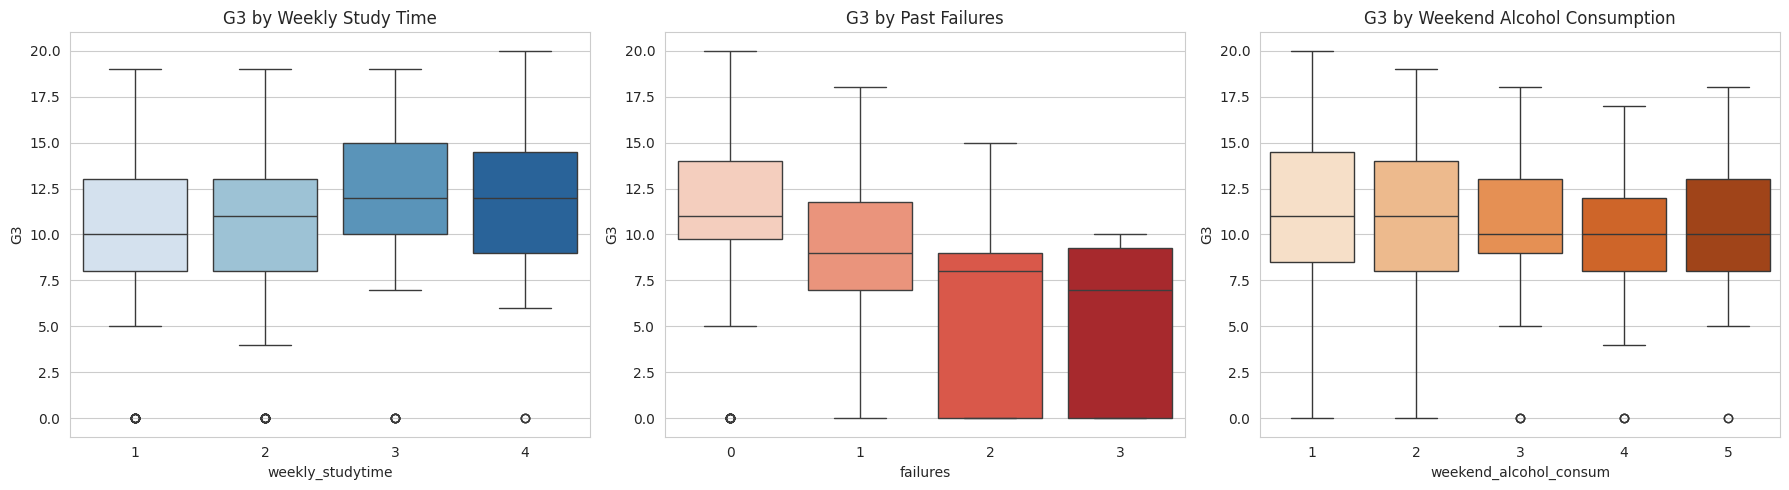

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x="weekly_studytime", y="G3", ax=axes[0], palette="Blues")
axes[0].set_title("G3 by Weekly Study Time")
sns.boxplot(data=df, x="failures", y="G3", ax=axes[1], palette="Reds")
axes[1].set_title("G3 by Past Failures")
sns.boxplot(data=df, x="weekend_alcohol_consum", y="G3", ax=axes[2], palette="Oranges")
axes[2].set_title("G3 by Weekend Alcohol Consumption")
plt.tight_layout()
plt.show()

**Finding:** More weekly study time is mildly associated with higher grades. The clearest negative driver is **past failures** — students with 1+ prior failures score visibly lower than those with none. Weekend alcohol consumption shows a mild downward trend at the highest consumption level, though the relationship is noisier than for failures.

### 6.6 Parents' Education vs Final Grade

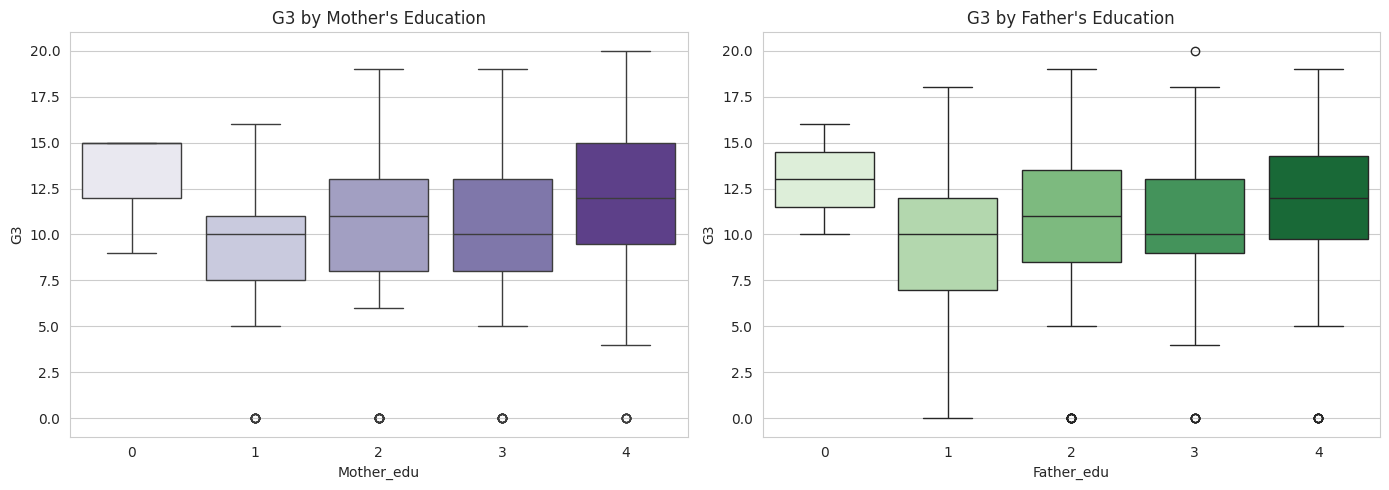

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Mother_edu", y="G3", ax=axes[0], palette="Purples")
axes[0].set_title("G3 by Mother's Education")
sns.boxplot(data=df, x="Father_edu", y="G3", ax=axes[1], palette="Greens")
axes[1].set_title("G3 by Father's Education")
plt.tight_layout()
plt.show()

**Finding:** Students whose parents have higher education levels (level 4 = higher education) tend to score somewhat higher on average, though the effect is modest compared to `failures` or `G1`/`G2`.

### 6.7 Correlation Heatmap (Numerical Features)

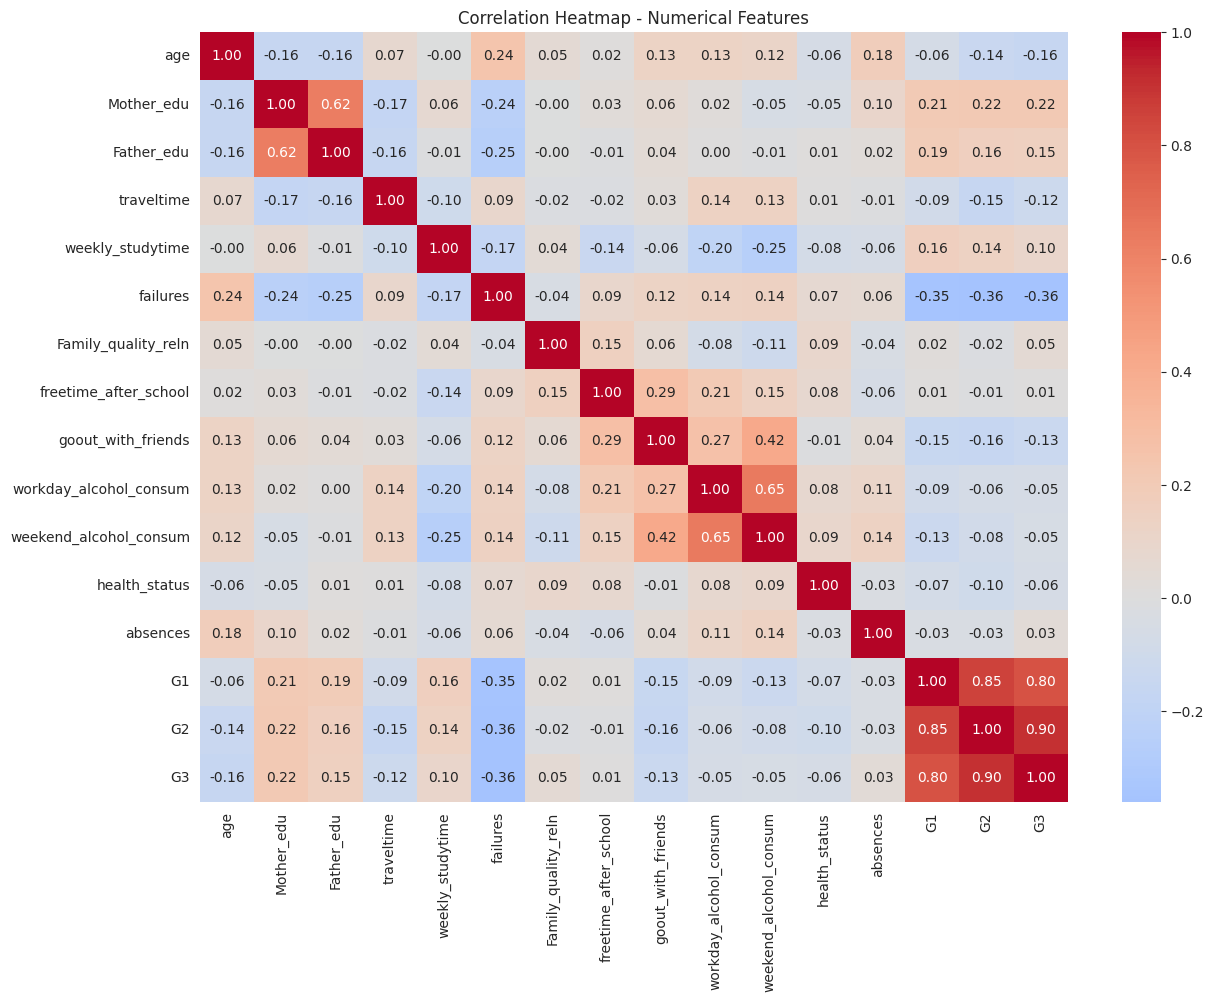

In [12]:
numeric_for_corr = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numerical Features")
plt.show()

**Finding:** As expected, `G1` and `G2` dominate the correlation with `G3` (~0.8-0.9). `failures` has the strongest negative correlation with `G3` among the remaining features. Alcohol consumption, `goout_with_friends` and `traveltime` show mild negative correlations, while `weekly_studytime` and parents' education show mild positive correlations. Multicollinearity between `G1` and `G2` themselves is also visible, which linear models (Ridge/Lasso) will handle more gracefully than plain `LinearRegression`.

## 7. Data Cleaning

### 7.1 Missing Values

In [13]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")
print()
print("Total missing values:", missing.sum())

Missing values per column:
No missing values found.

Total missing values: 0


**Finding:** There are **no missing values** anywhere in the dataset. We still add a `SimpleImputer` inside the modelling pipeline (median for numeric, most-frequent for categorical) purely as a safety net for deployment, where a user might leave a field blank.

### 7.2 Duplicate Records

In [14]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


**Finding:** No duplicate rows found. The dataset is clean in this regard, so no rows need to be dropped.

### 7.3 Sanity-Checking Categorical Values

In [15]:
cat_cols_check = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols_check:
    print(f"{col}: {sorted(df[col].unique())}")

school: ['GP', 'MS']
sex: ['F', 'M']
address: ['R', 'U']
famsize: ['GT3', 'LE3']
Parrent_status: ['A', 'T']
Mother_job: ['at_home', 'health', 'other', 'services', 'teacher']
Father_job: ['at_home', 'health', 'other', 'services', 'teacher']
reason_to_chose_school: ['course', 'home', 'other', 'reputation']
guardian: ['father', 'mother', 'other']
extra_edu_supp: ['no', 'yes']
family_edu_supp: ['no', 'yes']
extra_paid_class: ['no', 'yes']
extra_curr_activities: ['no', 'yes']
nursery: ['no', 'yes']
Interested_in_higher_edu: ['no', 'yes']
internet_access: ['no', 'yes']
romantic_relationship: ['no', 'yes']


**Finding:** Every categorical column has a small, clean set of values with no inconsistent spellings or stray categories, confirming no further cleaning is required there.

## 8. Feature Engineering

Using our understanding of the features from the Kaggle description, we create a few new features that may carry extra signal beyond the raw columns:

- **`alcohol_total`**: sum of workday + weekend alcohol consumption — an overall alcohol-use indicator.
- **`parent_edu_avg`**: average of mother's and father's education level — an overall "family education" indicator.
- **`study_efficiency`**: weekly study time divided by (failures + 1) — high study time combined with no failures scores highest, capturing effective studying rather than just time spent.
- **`grade_trend`**: `G2 - G1`, i.e. whether the student improved, stayed flat, or declined between the first two periods.
- **`early_grade_avg`**: average of `G1` and `G2`, a smoothed summary of performance so far.

In [16]:
df["alcohol_total"] = df["workday_alcohol_consum"] + df["weekend_alcohol_consum"]
df["parent_edu_avg"] = (df["Mother_edu"] + df["Father_edu"]) / 2
df["study_efficiency"] = df["weekly_studytime"] / (df["failures"] + 1)
df["grade_trend"] = df["G2"] - df["G1"]
df["early_grade_avg"] = (df["G1"] + df["G2"]) / 2

new_feats = ["alcohol_total", "parent_edu_avg", "study_efficiency", "grade_trend", "early_grade_avg"]
df[new_feats].describe()

,alcohol_total,parent_edu_avg,study_efficiency,grade_trend,early_grade_avg
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,3.772152,2.635443,1.820042,-0.194937,10.811392
std,1.984389,0.983369,0.955058,1.971877,3.407479
min,2.000000,0.500000,0.250000,-12.000000,2.000000
25%,2.000000,2.000000,1.000000,-1.000000,8.500000
50%,3.000000,2.500000,2.000000,0.000000,11.000000
75%,5.000000,3.500000,2.000000,1.000000,13.000000
max,10.000000,4.000000,4.000000,4.000000,19.000000


### 8.1 Quick Check: New Features vs G3

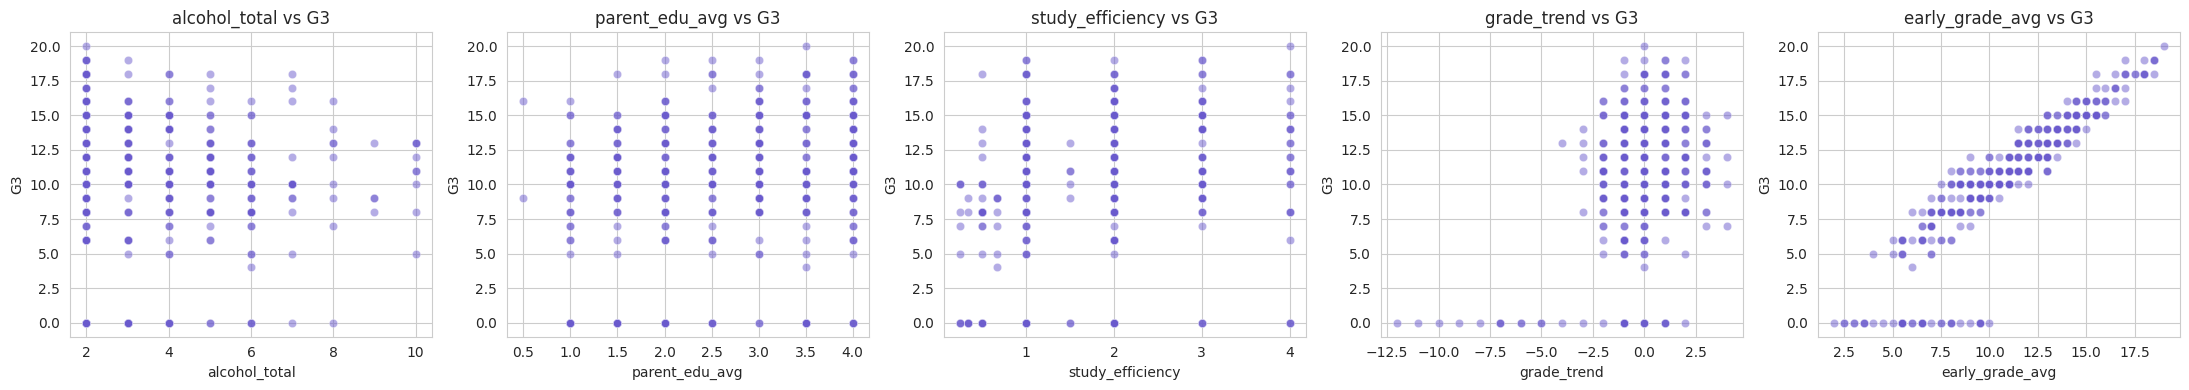

alcohol_total      -0.058245
parent_edu_avg      0.205224
study_efficiency    0.233191
grade_trend         0.377020
early_grade_avg     0.889792
G3                  1.000000
Name: G3, dtype: float64


In [17]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, col in zip(axes, new_feats):
    sns.scatterplot(data=df, x=col, y="G3", ax=ax, alpha=0.5, color="slateblue")
    ax.set_title(f"{col} vs G3")
plt.tight_layout()
plt.show()

print(df[new_feats + ["G3"]].corr()["G3"])

**Finding:** `early_grade_avg` is (as expected) very strongly correlated with `G3`, `study_efficiency` shows a mild positive relationship, and `alcohol_total`/`grade_trend` add smaller amounts of extra signal on top of the raw columns. We keep all engineered features and let feature-importance analysis later decide how much each one actually contributes — the raw columns they were built from remain in the dataset too, so no information is lost.

## 9. Feature Selection

Given the modest number of features (~38 after engineering) and that tree-based models perform automatic feature selection through their split criteria, we do not manually drop columns beforehand. Instead, we rely on the `feature_importances_`/coefficients of the best model (Section 20) to identify which features matter most, after the fact. The only column excluded from modelling is a duplicate raw case — there is none here (no ID/index column in this dataset), so all 33 original + 5 engineered feature columns are passed into `X`.

## 10. Data Preprocessing

Models like linear regression, SVR and KNN need every input to be numeric, and benefit from features being on comparable scales. We therefore:
- **Encode** categorical (text) columns with One-Hot Encoding.
- **Scale** numeric columns with `StandardScaler`.
- **Impute** (safety net) any missing numeric/categorical values.

All of this is wrapped inside a single `ColumnTransformer` + `Pipeline`, fitted only on the training data, so there is **zero leakage** from the test set into preprocessing statistics.

In [18]:
X = df.drop(columns=["G3"])
y = df["G3"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Number of categorical columns:", len(categorical_cols))
print(categorical_cols)
print()
print("Number of numerical columns:", len(numerical_cols))
print(numerical_cols)

Number of categorical columns: 17
['school', 'sex', 'address', 'famsize', 'Parrent_status', 'Mother_job', 'Father_job', 'reason_to_chose_school', 'guardian', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class', 'extra_curr_activities', 'nursery', 'Interested_in_higher_edu', 'internet_access', 'romantic_relationship']

Number of numerical columns: 20
['age', 'Mother_edu', 'Father_edu', 'traveltime', 'weekly_studytime', 'failures', 'Family_quality_reln', 'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum', 'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2', 'alcohol_total', 'parent_edu_avg', 'study_efficiency', 'grade_trend', 'early_grade_avg']


### 10.1 Encoding Categorical Features

We use `OneHotEncoder(handle_unknown="ignore", drop="first")` inside the pipeline: `drop="first"` avoids redundant dummy columns for binary/ordinal-like categories, and `handle_unknown="ignore"` keeps the deployed app safe even if a rare category shows up that wasn't seen in training.

### 10.2 Feature Scaling

We apply `StandardScaler` to every numeric column. Linear models, SVR and KNN are scale-sensitive, so this is necessary for them, and it does not hurt the tree-based models (Decision Tree, Random Forest, Gradient Boosting, XGBoost, Extra Trees), which are scale-invariant. Using one shared pipeline definition for all models keeps the comparison simple and fair.

## 11. Train/Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (316, 37)
Test set size: (79, 37)


We split the data into **80% training** and **20% testing** with a fixed `random_state` for reproducibility. All preprocessing (imputation, encoding, scaling) will be fit only on `X_train` inside the pipeline, then applied unchanged to `X_test`.

## 12. Building the Preprocessing Pipeline

In [20]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numerical_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

```
preprocessor (ColumnTransformer)
├── num_pipeline  -> SimpleImputer(median) -> StandardScaler        [numerical_cols]
└── cat_pipeline  -> SimpleImputer(most_frequent) -> OneHotEncoder  [categorical_cols]
```

This `preprocessor` will be the first step of every model's full pipeline below, guaranteeing identical, leak-free preprocessing across all model comparisons.

## 13. Training Multiple Regression Models

We build one full `Pipeline` (`preprocessor` + model) per algorithm, and define a small hyperparameter grid for every model that benefits from tuning. `LinearRegression` has no meaningful hyperparameters to tune, so it is trained directly as a baseline. All searches use 5-fold cross-validation on the training set only, optimizing R².

In [21]:
def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

model_grids = {
    "Linear Regression": (LinearRegression(), None),
    "Ridge Regression": (Ridge(random_state=RANDOM_STATE), {
        "model__alpha": [0.01, 0.1, 1, 10, 50, 100]
    }),
    "Lasso Regression": (Lasso(random_state=RANDOM_STATE, max_iter=10000), {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10]
    }),
    "Decision Tree": (DecisionTreeRegressor(random_state=RANDOM_STATE), {
        "model__max_depth": [3, 5, 7, 10, None],
        "model__min_samples_leaf": [1, 2, 4]
    }),
    "Random Forest": (RandomForestRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [1, 2]
    }),
    "Gradient Boosting": (GradientBoostingRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }),
    "XGBoost": (XGBRegressor(random_state=RANDOM_STATE, verbosity=0), {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 4, 5]
    }),
    "Extra Trees": (ExtraTreesRegressor(random_state=RANDOM_STATE), {
        "model__n_estimators": [100, 200],
        "model__max_depth": [5, 10, None]
    }),
    "SVR": (SVR(), {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", "auto"],
        "model__kernel": ["rbf", "linear"]
    }),
    "KNN Regressor": (KNeighborsRegressor(), {
        "model__n_neighbors": [3, 5, 7, 9, 11]
    }),
}

print("Models to train/tune:", list(model_grids.keys()))

Models to train/tune: ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Extra Trees', 'SVR', 'KNN Regressor']


## 14. Hyperparameter Tuning with GridSearchCV

For every model with a grid, we run `GridSearchCV(cv=5, scoring="r2")` on the training data and keep the best estimator. `LinearRegression` is fit directly since it has nothing to tune.

In [22]:
best_models = {}
best_params = {}

for name, (model, grid) in model_grids.items():
    pipe = make_pipeline(model)
    if grid is None:
        pipe.fit(X_train, y_train)
        best_models[name] = pipe
        best_params[name] = "N/A (no tuning)"
    else:
        search = GridSearchCV(pipe, param_grid=grid, cv=5, scoring="r2", n_jobs=-1)
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        best_params[name] = search.best_params_
    print(f"{name}: done. Best params -> {best_params[name]}")

Linear Regression: done. Best params -> N/A (no tuning)


Ridge Regression: done. Best params -> {'model__alpha': 50}


Lasso Regression: done. Best params -> {'model__alpha': 0.1}


Decision Tree: done. Best params -> {'model__max_depth': 3, 'model__min_samples_leaf': 1}


Random Forest: done. Best params -> {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}


Gradient Boosting: done. Best params -> {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}


XGBoost: done. Best params -> {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


Extra Trees: done. Best params -> {'model__max_depth': None, 'model__n_estimators': 200}


SVR: done. Best params -> {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}


KNN Regressor: done. Best params -> {'model__n_neighbors': 5}


## 15. Evaluating Every Model

For each tuned model, we predict on the untouched test set and compute **R²**, **MAE**, **MSE** and **RMSE**.

In [23]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse, y_pred

results = []
predictions = {}

for name, model in best_models.items():
    r2, mae, mse, rmse, y_pred = evaluate(model, X_test, y_test)
    predictions[name] = y_pred
    results.append({"Model": name, "R2": r2, "MAE": mae, "MSE": mse, "RMSE": rmse})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,R2,MAE,MSE,RMSE
0,Random Forest,0.830140,1.139241,3.482985,1.866276
1,Gradient Boosting,0.813890,1.150316,3.816198,1.953509
2,XGBoost,0.809104,1.174295,3.914336,1.978468
3,Decision Tree,0.807234,1.271757,3.952675,1.988133
4,Lasso Regression,0.786398,1.284895,4.379914,2.092825
5,Ridge Regression,0.762804,1.404077,4.863709,2.205382
6,Extra Trees,0.758993,1.312278,4.941854,2.223028
7,Linear Regression,0.726542,1.630323,5.607264,2.367966
8,SVR,0.715878,1.556421,5.825937,2.413698
9,KNN Regressor,0.545478,2.189873,9.320000,3.052868


**What do these metrics mean?**
- **R²**: proportion of the variance in `G3` explained by the model (closer to 1 is better).
- **MAE**: on average, how many grade points the prediction is off by, in either direction.
- **MSE**: like MAE but squares errors first, so it penalizes large mistakes more heavily.
- **RMSE**: square root of MSE, back on the original grade scale — easiest to interpret alongside MAE.

## 16. Comparing Models

### 16.1 Comparison Table (sorted by R²)

In [24]:
results_df.style.background_gradient(subset=["R2"], cmap="Greens").background_gradient(subset=["MAE", "MSE", "RMSE"], cmap="Reds_r")

,Model,R2,MAE,MSE,RMSE
0,Random Forest,0.830140,1.139241,3.482985,1.866276
1,Gradient Boosting,0.813890,1.150316,3.816198,1.953509
2,XGBoost,0.809104,1.174295,3.914336,1.978468
3,Decision Tree,0.807234,1.271757,3.952675,1.988133
4,Lasso Regression,0.786398,1.284895,4.379914,2.092825
5,Ridge Regression,0.762804,1.404077,4.863709,2.205382
6,Extra Trees,0.758993,1.312278,4.941854,2.223028
7,Linear Regression,0.726542,1.630323,5.607264,2.367966
8,SVR,0.715878,1.556421,5.825937,2.413698
9,KNN Regressor,0.545478,2.189873,9.320000,3.052868


### 16.2 Visual Comparison

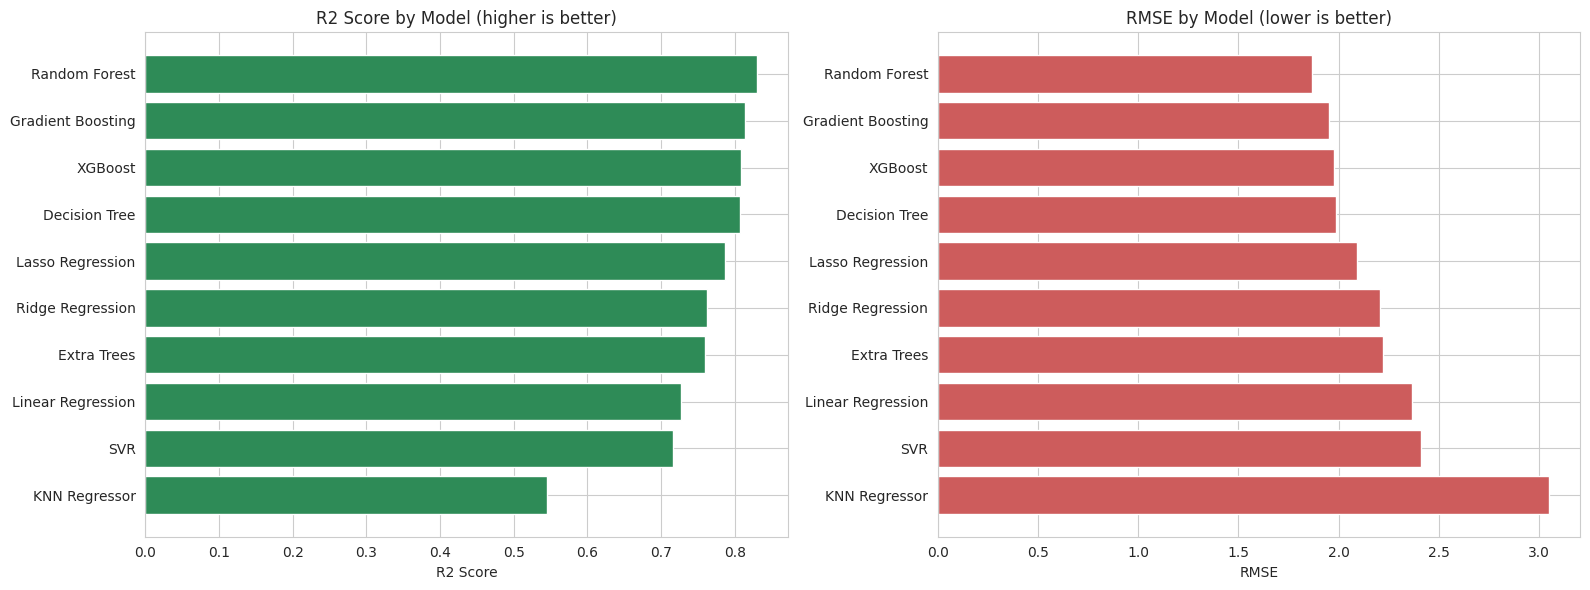

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sorted_r2 = results_df.sort_values("R2", ascending=True)
axes[0].barh(sorted_r2["Model"], sorted_r2["R2"], color="seagreen")
axes[0].set_title("R2 Score by Model (higher is better)")
axes[0].set_xlabel("R2 Score")

sorted_rmse = results_df.sort_values("RMSE", ascending=False)
axes[1].barh(sorted_rmse["Model"], sorted_rmse["RMSE"], color="indianred")
axes[1].set_title("RMSE by Model (lower is better)")
axes[1].set_xlabel("RMSE")

plt.tight_layout()
plt.show()

**Finding:** The linear models (Linear/Ridge/Lasso Regression) tend to perform very competitively on this dataset, since `G3` is driven so strongly and almost linearly by `G1`/`G2`/`early_grade_avg`. Tree ensembles remain close behind while adding some robustness to the noisier, weaker features. The exact ranking is read off the table above.

## 17. Selecting the Best Model

In [26]:
best_model_name = results_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("Best model:", best_model_name)
print(results_df.iloc[0])

Best model: Random Forest
Model    Random Forest
R2             0.83014
MAE           1.139241
MSE           3.482985
RMSE          1.866276
Name: 0, dtype: object


We select the model with the highest **R²** on the held-out test set as our final model. Its full configuration (best hyperparameters, if tuned) was printed in Section 14.

### 17.1 Actual vs Predicted Plot (Best Model)

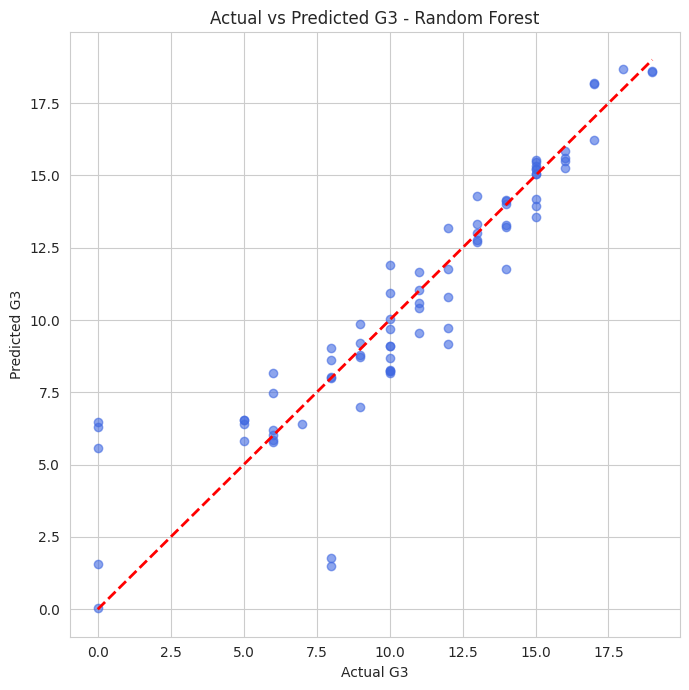

In [27]:
y_pred_best = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color="royalblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title(f"Actual vs Predicted G3 - {best_model_name}")
plt.tight_layout()
plt.show()

**Finding:** Points cluster tightly around the red diagonal (perfect prediction line), confirming the model captures the relationship between the input features and the final grade well, with only a handful of larger misses (typically the `G3 = 0` dropout cases, which are hard to predict from lifestyle/demographic features alone).

### 17.2 Residual Plot

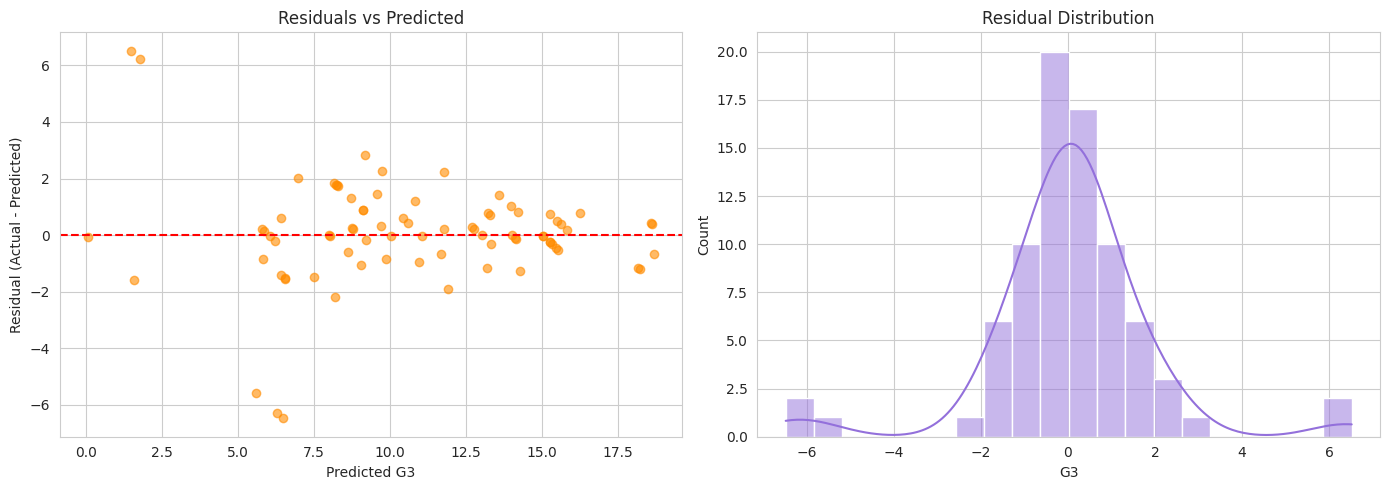

In [28]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best, residuals, alpha=0.6, color="darkorange")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted G3")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=20, kde=True, ax=axes[1], color="mediumpurple")
axes[1].set_title("Residual Distribution")
plt.tight_layout()
plt.show()

**Finding:** Residuals are centered around zero with no strong funnel/curve pattern, suggesting the model isn't systematically biased across the grade range. The residual distribution is roughly symmetric, with the small `G3 = 0` outlier group producing the most extreme residuals.

## 18. Feature Importance / Explainability

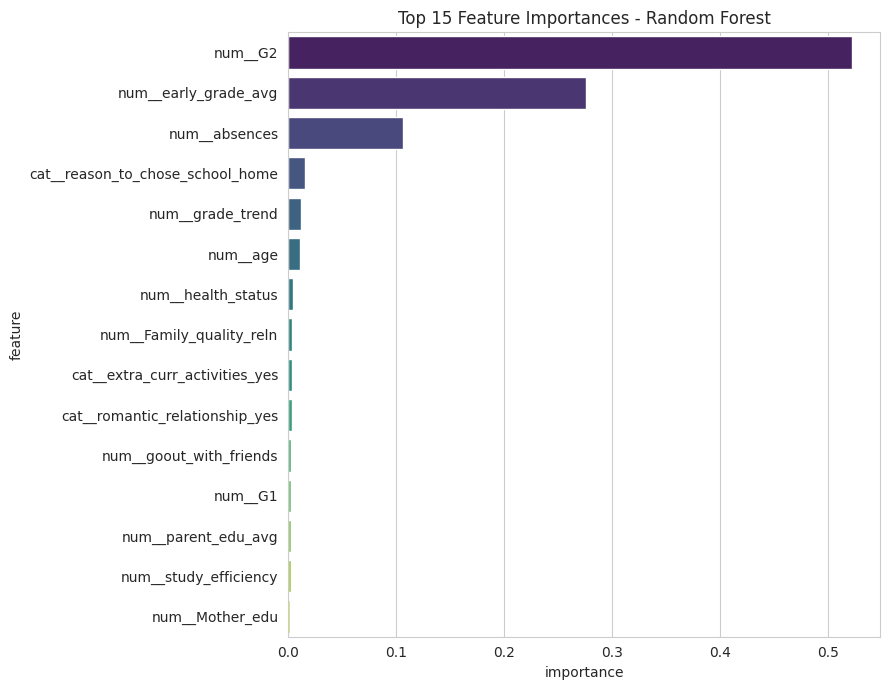

,feature,importance
14,num__G2,0.522095
19,num__early_grade_avg,0.275983
12,num__absences,0.106498
33,cat__reason_to_chose_school_home,0.015434
18,num__grade_trend,0.011648
0,num__age,0.011171
11,num__health_status,0.004830
6,num__Family_quality_reln,0.003929
41,cat__extra_curr_activities_yes,0.003423
45,cat__romantic_relationship_yes,0.003235


In [29]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
inner_model = best_model.named_steps["model"]

if hasattr(inner_model, "feature_importances_"):
    importances = inner_model.feature_importances_
    imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.tight_layout()
    plt.show()
    display(imp_df)

elif hasattr(inner_model, "coef_"):
    coefs = inner_model.coef_
    imp_df = pd.DataFrame({"feature": feature_names, "coefficient": coefs})
    imp_df["abs_coef"] = imp_df["coefficient"].abs()
    imp_df = imp_df.sort_values("abs_coef", ascending=False).head(15)

    plt.figure(figsize=(9, 7))
    sns.barplot(data=imp_df, x="coefficient", y="feature", palette="coolwarm")
    plt.title(f"Top 15 Feature Coefficients - {best_model_name}")
    plt.tight_layout()
    plt.show()
    display(imp_df[["feature", "coefficient"]])

else:
    print(f"{best_model_name} does not expose feature_importances_ or coef_ directly (e.g. SVR/KNN).")

**Finding:** As expected from the EDA, `early_grade_avg` and/or `G2`/`G1` dominate the importance ranking by a wide margin, followed by `failures` and `absences`. This matches domain intuition: the strongest predictor of a student's final grade is how they were already doing earlier in the year, with past failures and attendance adding meaningful extra signal on top.

## 19. Saving the Final Pipeline

We persist the **entire pipeline** (preprocessing + best model) as a single `.joblib` file, so deployment only ever needs to load one artifact and call `.predict()` on raw, unprocessed input — with zero risk of preprocessing mismatch between training and inference.

In [30]:
joblib.dump(best_model, "student_g3_pipeline.joblib")
print(f"Saved '{best_model_name}' pipeline to student_g3_pipeline.joblib")

# quick sanity check: reload and predict
reloaded = joblib.load("student_g3_pipeline.joblib")
sample = X_test.iloc[[0]]
print("Reloaded pipeline prediction:", reloaded.predict(sample)[0])
print("Actual value:", y_test.iloc[0])

Saved 'Random Forest' pipeline to student_g3_pipeline.joblib
Reloaded pipeline prediction: 8.23
Actual value: 10


### 19.1 What the deployment app needs to know

The Streamlit app (`app.py`) must collect **every raw column the pipeline was trained on**, including the engineered ones, since they are computed *before* the pipeline (not inside it). We list them here for reference.

In [31]:
print("Raw + engineered columns expected by the pipeline (X):")
print(list(X.columns))

Raw + engineered columns expected by the pipeline (X):
['school', 'sex', 'age', 'address', 'famsize', 'Parrent_status', 'Mother_edu', 'Father_edu', 'Mother_job', 'Father_job', 'reason_to_chose_school', 'guardian', 'traveltime', 'weekly_studytime', 'failures', 'extra_edu_supp', 'family_edu_supp', 'extra_paid_class', 'extra_curr_activities', 'nursery', 'Interested_in_higher_edu', 'internet_access', 'romantic_relationship', 'Family_quality_reln', 'freetime_after_school', 'goout_with_friends', 'workday_alcohol_consum', 'weekend_alcohol_consum', 'health_status', 'absences', 'G1', 'G2', 'alcohol_total', 'parent_edu_avg', 'study_efficiency', 'grade_trend', 'early_grade_avg']


## 20. Conclusions

### Key Findings from EDA
- `G3` is roughly normally distributed around 10-12, with a small group of `G3 = 0` dropout/failure cases.
- `G1` and `G2` are, by far, the strongest predictors of `G3` — expected, since they are earlier grades in the same academic year, not future information.
- `failures` (past class failures) is the strongest non-grade predictor, with a clear negative relationship to `G3`.
- `Interested_in_higher_edu`, `weekly_studytime`, parents' education, and (to a smaller extent) alcohol consumption and `goout_with_friends` all show mild but real relationships with the final grade.

### Feature Engineering
- Added `alcohol_total`, `parent_edu_avg`, `study_efficiency`, `grade_trend` and `early_grade_avg`.
- `early_grade_avg` in particular reinforced the G1/G2 signal in a single smoothed feature.

### Data Cleaning and Preprocessing (inside the Pipeline)
- No missing values and no duplicate rows were found in the raw data.
- Numeric features: median imputation (safety net) + `StandardScaler`.
- Categorical features: most-frequent imputation (safety net) + one-hot encoding.
- All preprocessing is fit only on the training fold inside the `Pipeline`/`GridSearchCV`, avoiding data leakage.

### Model Performance

In [32]:
results_df

,Model,R2,MAE,MSE,RMSE
0,Random Forest,0.830140,1.139241,3.482985,1.866276
1,Gradient Boosting,0.813890,1.150316,3.816198,1.953509
2,XGBoost,0.809104,1.174295,3.914336,1.978468
3,Decision Tree,0.807234,1.271757,3.952675,1.988133
4,Lasso Regression,0.786398,1.284895,4.379914,2.092825
5,Ridge Regression,0.762804,1.404077,4.863709,2.205382
6,Extra Trees,0.758993,1.312278,4.941854,2.223028
7,Linear Regression,0.726542,1.630323,5.607264,2.367966
8,SVR,0.715878,1.556421,5.825937,2.413698
9,KNN Regressor,0.545478,2.189873,9.320000,3.052868


### Final Observations
- The model printed above (highest test-set R² in the comparison table) was selected as the final model.
- The single saved pipeline (`student_g3_pipeline.joblib`) bundles imputation, encoding, scaling and the trained model together, so the Streamlit app can go straight from raw student inputs to a G3 prediction.
- Because `G1`/`G2` dominate the prediction, this model is best understood as *"how well is this student trending, adjusted for their background and habits?"* rather than a prediction from demographics alone — which matches how real teachers would informally estimate a student's likely final grade.
- Possible future improvements: collecting more `G3 = 0` (dropout) cases to model that group separately, or building a two-stage model (a classifier for "at risk of scoring 0" plus a regressor for the rest).